In [1]:
import numpy as np 
import pandas as pd 
from statsmodels.stats.weightstats import ztest
np.random.seed(50) 
n_employees = 50 
emp_ids = [f"EMP_{i:03d}" for i in range(1, n_employees + 1)]
speed_old_software = np.random.normal(loc=25,scale=4,size=n_employees) 
speed_new_software = np.random.normal(loc=28,scale=5,size=n_employees) 
df_project = pd.DataFrame({
    'Employee_ID':emp_ids,
    'Old_Software_Speed_Hr':speed_new_software, 
    'New_Software_Speed_Hr':speed_old_software
}) 
print("===First 5 ROWS OF OUR BANKING DATA===") 
print(df_project.head())

===First 5 ROWS OF OUR BANKING DATA===
  Employee_ID  Old_Software_Speed_Hr  New_Software_Speed_Hr
0     EMP_001              24.033917              18.758592
1     EMP_002              27.805823              24.876090
2     EMP_003              41.526275              22.516286
3     EMP_004              20.543057              19.141678
4     EMP_005              28.479890              30.647784


In [2]:
print("\nDATA SUMMARY (EDA)") 
print(F"Old Software Avrage Speed: {df_project['Old_Software_Speed_Hr'].mean():.2f}") 
print(f"New Software Avrage Speed: {df_project['New_Software_Speed_Hr'].mean():.2f}") 


DATA SUMMARY (EDA)
Old Software Avrage Speed: 27.93
New Software Avrage Speed: 25.37


In [3]:
z_cal,p_val = ztest(df_project['Old_Software_Speed_Hr'],df_project['New_Software_Speed_Hr']) 
print("\nHYPOTHESIS TESTING RESULT") 
print(f"Z-Calculated Value: {z_cal:.4f}") 
print(f"P-Value: {p_val:4f}") 


HYPOTHESIS TESTING RESULT
Z-Calculated Value: 2.5686
P-Value: 0.010210


In [4]:
print("\n FINAL BUSINESS DECISION") 
if p_val < 0.05: 
    print("Result: Significant Difference Found") 
    print("Decision: Reject Null Hypothesis") 
else: 
    print("Result: No Significant Difference Found") 
    print("Decision: Not Rejected Null Hypothesis") 


 FINAL BUSINESS DECISION
Result: Significant Difference Found
Decision: Reject Null Hypothesis


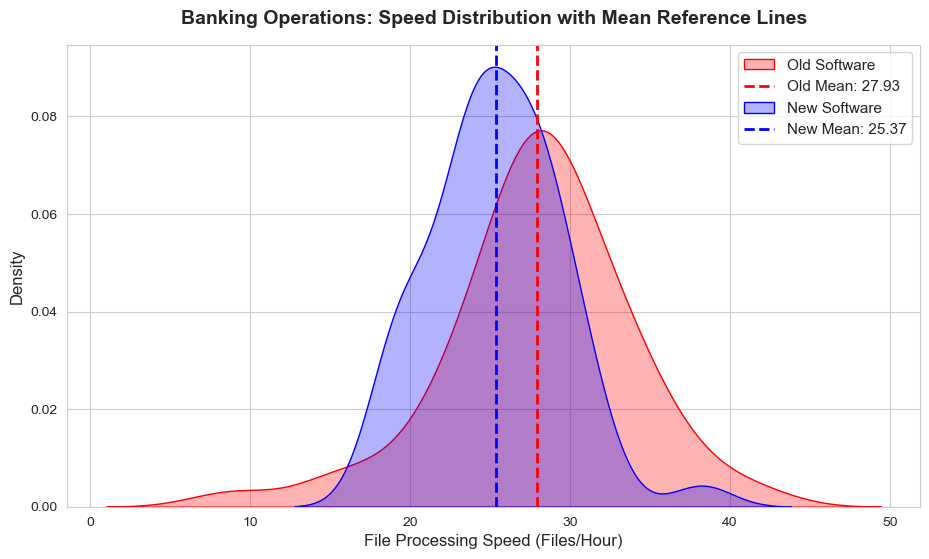

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(11, 6))
sns.set_style("whitegrid")
old_mean = df_project['Old_Software_Speed_Hr'].mean()
new_mean = df_project['New_Software_Speed_Hr'].mean()
sns.kdeplot(data=df_project, x='Old_Software_Speed_Hr', fill=True, color="red", label="Old Software", alpha=0.3)
plt.axvline(x=old_mean, color="red", linestyle="--", linewidth=2, label=f"Old Mean: {old_mean:.2f}")
sns.kdeplot(data=df_project, x='New_Software_Speed_Hr', fill=True, color="blue", label="New Software", alpha=0.3)
plt.axvline(x=new_mean, color="blue", linestyle="--", linewidth=2, label=f"New Mean: {new_mean:.2f}")
plt.title("Banking Operations: Speed Distribution with Mean Reference Lines", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("File Processing Speed (Files/Hour)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=11, loc="upper right")
plt.show()